# Project 08 — Oceanic tool kits (Poisson regression)

**Tier 2 · Generalised linear models** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P08_oceanic-poisson/P08_oceanic-poisson_12-06-2026_Opus48.ipynb)

Ten Oceanic societies: does a larger **population** (and **contact** with other islands) support a
larger **tool kit**? New skills: the **log link** of Poisson regression, an **interaction on the count
scale**, and seeing why the intercept prior `Normal(3, 0.5)` — not the "flat" `Normal(0, 10)` — keeps
predicted tool counts in the hundreds rather than the millions (Kline & Boyd 2010).

## Learning objectives
1. Build a **Poisson GLM** `total_tools ~ Poisson(lambda)` with `log(lambda)` linear predictor.
2. Standardize `log(population)` and code contact as 0/1; add a **population × contact interaction**.
3. Run the **prior predictive on the count scale** and defend `a ~ Normal(3, 0.5)`.
4. Compare with vs without the interaction via **PSIS-LOO**, reporting Pareto-k̂ honestly for n = 10.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
RANDOM_SEED = 8
rng = np.random.default_rng(RANDOM_SEED)
trapz = getattr(np, "trapezoid", None) or np.trapz   # NumPy 2.x renamed trapz->trapezoid
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate `total_tools ~ Poisson(exp(a + b_p*P + b_c*contact))` from known params; fit; confirm recovery.

In [2]:
a_t, bp_t, bc_t = 3.2, 0.3, 0.2
n_sim = 60
P_sim = rng.normal(0, 1, n_sim)
contact_sim = rng.integers(0, 2, n_sim)
lam = np.exp(a_t + bp_t*P_sim + bc_t*contact_sim)
y_sim = rng.poisson(lam)
with pm.Model() as m0:
    a = pm.Normal("a", 3, 0.5); b_p = pm.Normal("b_p", 0, 0.5); b_c = pm.Normal("b_c", 0, 0.5)
    pm.Poisson("y", pm.math.exp(a + b_p*P_sim + b_c*contact_sim), observed=y_sim)
    idata0 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                       random_seed=RANDOM_SEED, progressbar=False)
s0 = az.summary(idata0, hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat","ess_bulk"]])
for nm, tr in [("a",a_t),("b_p",bp_t),("b_c",bc_t)]:
    print(nm, "recovered:", s0.loc[nm,"hdi_5%"] <= tr <= s0.loc[nm,"hdi_95%"])

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b_p, b_c]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


      mean  hdi_5%  hdi_95%  r_hat  ess_bulk
a    3.206   3.149    3.268    1.0    2006.0
b_p  0.303   0.268    0.340    1.0    2279.0
b_c  0.249   0.164    0.324    1.0    2009.0
a recovered: True
b_p recovered: True
b_c recovered: True


## Data load — Kline (`;`-delimited)

In [3]:
URL = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Kline.csv"
CACHE = "data/Kline.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw), sep=";"); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE, sep=";")
df

loaded from raw URL


,culture,population,contact,total_tools,mean_TU
0,Malekula,1100,low,13,3.2
1,Tikopia,1500,low,22,4.7
2,Santa Cruz,3600,low,24,4.0
3,Yap,4791,high,43,5.0
4,Lau Fiji,7400,high,33,5.0
5,Trobriand,8000,high,19,4.0
6,Chuuk,9200,high,40,3.8
7,Manus,13000,low,28,6.6
8,Tonga,17500,high,55,5.4
9,Hawaii,275000,low,71,6.6


## Stage 1–2 — Question & EDA
**Question:** how does tool-kit size scale with (log) population, and does **contact** with other
islands change that scaling? **Target:** the population slope `b_p` and the interaction `b_pc`.
**Unit:** one society. We standardize `log(population)` → P and code contact `high=1 / low=0`.

n = 10 | total_tools range: 13 to 71
   culture  population contact  total_tools         P  contact_high
  Malekula        1100     low           13 -1.291473             0
   Tikopia        1500     low           22 -1.088551             0
Santa Cruz        3600     low           24 -0.515765             0
       Yap        4791    high           43 -0.328773             1
  Lau Fiji        7400    high           33 -0.044339             1
 Trobriand        8000    high           19  0.006668             1
     Chuuk        9200    high           40  0.098109             1
     Manus       13000     low           28  0.324318             0
     Tonga       17500    high           55  0.518798             1
    Hawaii      275000     low           71  2.321008             0


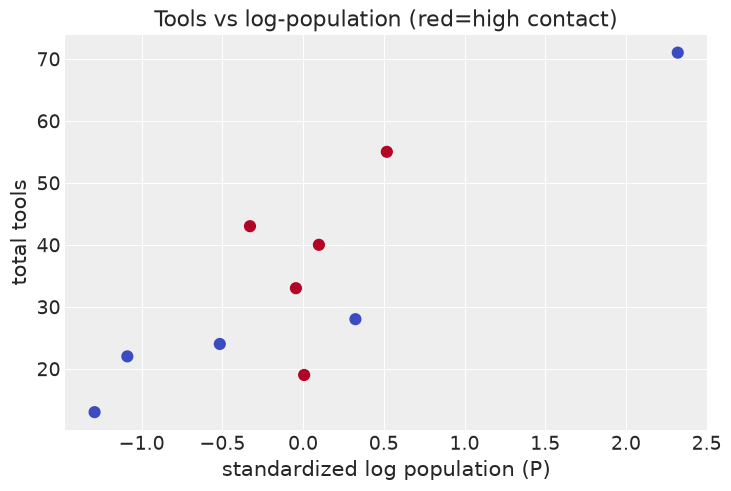

In [4]:
df = df.copy()
df["logpop"] = np.log(df["population"])
df["P"] = (df["logpop"] - df["logpop"].mean())/df["logpop"].std()
df["contact_high"] = (df["contact"] == "high").astype(int)
P = df["P"].values; contact = df["contact_high"].values; tools = df["total_tools"].values
print("n =", len(df), "| total_tools range:", tools.min(), "to", tools.max())
print(df[["culture","population","contact","total_tools","P","contact_high"]].to_string(index=False))
plt.scatter(df["P"], tools, c=contact, cmap="coolwarm", s=60)
plt.xlabel("standardized log population (P)"); plt.ylabel("total tools")
plt.title("Tools vs log-population (red=high contact)"); plt.show()

## Stage 3 — Model specification (two models)
**Model M1 (no interaction):** $\log\lambda_i = a + b_P P_i + b_c c_i$.
**Model M2 (with interaction):** $\log\lambda_i = a + b_P P_i + b_c c_i + b_{Pc} P_i c_i$.
$$\text{total\_tools}_i \sim \mathrm{Poisson}(\lambda_i),\quad a\sim\mathrm{Normal}(3,0.5),\ b\sim\mathrm{Normal}(0,0.5).$$
`a ~ Normal(3, 0.5)` puts the intercept tool count near `exp(3) ≈ 20` — defended in Stage 4.

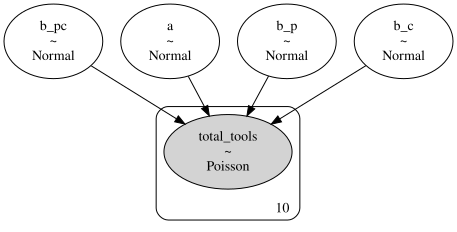

In [5]:
def make_model(interaction):
    with pm.Model() as m:
        a = pm.Normal("a", 3, 0.5)
        b_p = pm.Normal("b_p", 0, 0.5)
        b_c = pm.Normal("b_c", 0, 0.5)
        eta = a + b_p*P + b_c*contact
        if interaction:
            b_pc = pm.Normal("b_pc", 0, 0.5)
            eta = eta + b_pc*P*contact
        pm.Poisson("total_tools", pm.math.exp(eta), observed=tools)
    return m
model_m1 = make_model(False)
model_m2 = make_model(True)
try:
    display(pm.model_to_graphviz(model_m2))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| DAG: a,b_p,b_c,b_pc -> lambda -> total_tools")

## Stage 4 — Prior predictive on the COUNT scale (defend a ~ Normal(3, 0.5))
Compare the chosen intercept prior against a "flat" `Normal(0, 10)`: the flat prior implies tool counts
in the **millions** (absurd for islands), while `Normal(3, 0.5)` keeps them in the tens-to-hundreds.

flat a~Normal(0,10):  median predicted tools = 1, 95th pct = 15,614,467
chosen a~Normal(3,0.5): median predicted tools = 20, 95th pct = 45


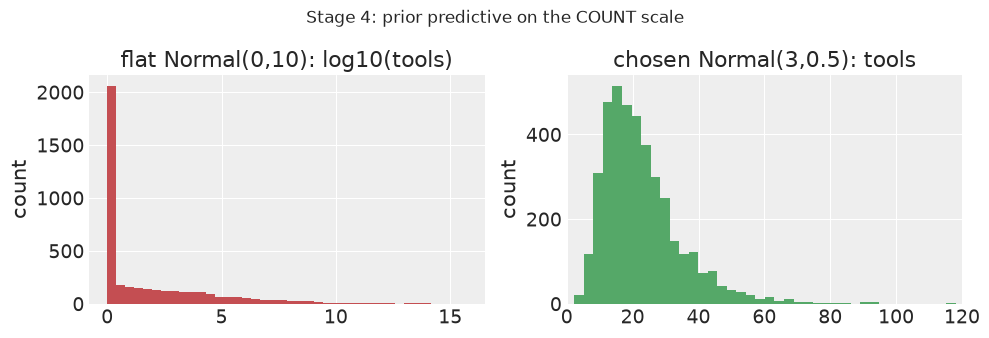

In [6]:
def prior_counts(a_mu, a_sd, n=4000):
    a = rng.normal(a_mu, a_sd, n); bp = rng.normal(0, 0.5, n)
    return np.exp(a + bp*0.0)   # at mean population P=0
flat = prior_counts(0, 10); chosen = prior_counts(3, 0.5)
print(f"flat a~Normal(0,10):  median predicted tools = {np.median(flat):.0f}, 95th pct = {np.quantile(flat,.95):,.0f}")
print(f"chosen a~Normal(3,0.5): median predicted tools = {np.median(chosen):.0f}, 95th pct = {np.quantile(chosen,.95):.0f}")
fig, ax = plt.subplots(1,2,figsize=(10,3.4))
ax[0].hist(np.log10(flat+1), bins=40, color="#c44e52"); ax[0].set_title("flat Normal(0,10): log10(tools)")
ax[1].hist(chosen, bins=40, color="#55a868"); ax[1].set_xlim(0,120); ax[1].set_title("chosen Normal(3,0.5): tools")
for a in ax: a.set_ylabel("count")
plt.suptitle("Stage 4: prior predictive on the COUNT scale"); plt.tight_layout(); plt.show()

## Stage 5 — Fit both models (with log-likelihood for LOO)

In [7]:
with model_m1:
    idata_m1 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                         progressbar=False, idata_kwargs={"log_likelihood": True})
    idata_m1.extend(pm.sample_posterior_predictive(idata_m1, random_seed=RANDOM_SEED, progressbar=False))
with model_m2:
    idata_m2 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                         progressbar=False, idata_kwargs={"log_likelihood": True})
    idata_m2.extend(pm.sample_posterior_predictive(idata_m2, random_seed=RANDOM_SEED, progressbar=False))
print("both models sampled")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b_p, b_c]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


Sampling: [total_tools]


...

Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b_p, b_c, b_pc]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Sampling: [total_tools]


both models sampled


## Stage 6 — Diagnostics

=== M1 no-interaction ===
      mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a    3.311  0.088   3.144    3.473    1.0    1873.0    1968.0
b_p  0.401  0.053   0.298    0.495    1.0    2134.0    2382.0
b_c  0.292  0.113   0.082    0.502    1.0    1906.0    2263.0
divergences: 0 | BFMI: [1.06 1.06 1.1  1.01] | max R-hat: 1.0 | min ESS-bulk: 1873.0 

=== M2 interaction ===
       mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a     3.312  0.086   3.148    3.471    1.0    2316.0    2463.0
b_p   0.398  0.051   0.299    0.493    1.0    2943.0    2808.0
b_c   0.280  0.112   0.064    0.488    1.0    2374.0    2654.0
b_pc  0.084  0.231  -0.358    0.503    1.0    2942.0    2373.0
divergences: 0 | BFMI: [1.02 1.07 1.1  1.  ] | max R-hat: 1.0 | min ESS-bulk: 2316.0 



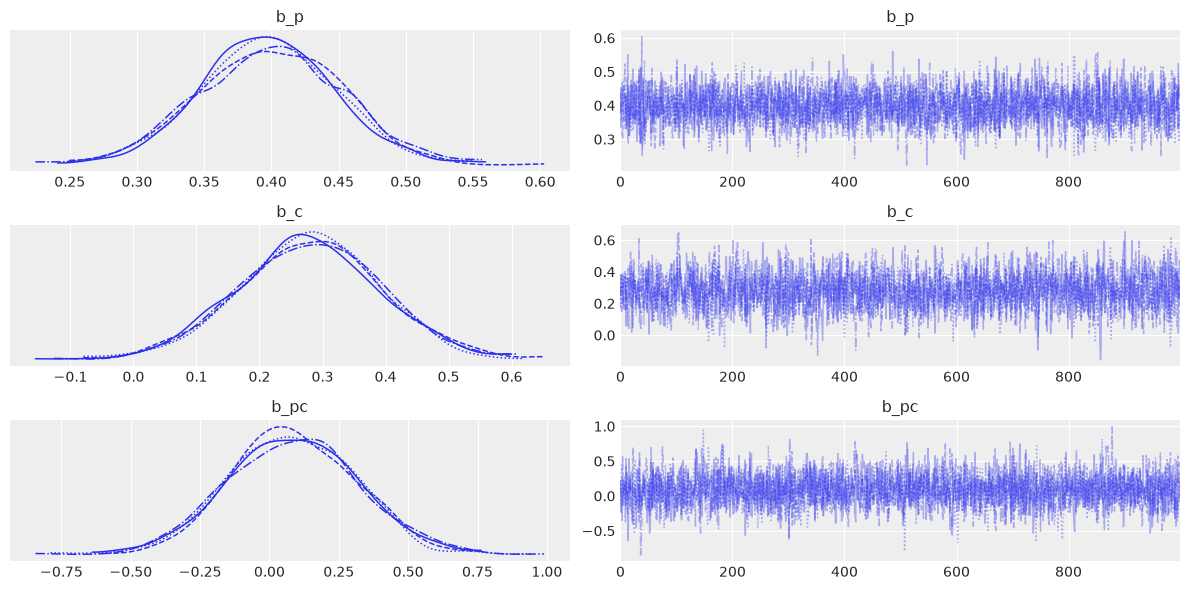

In [8]:
for name, idata in [("M1 no-interaction", idata_m1), ("M2 interaction", idata_m2)]:
    s = az.summary(idata, hdi_prob=0.94)
    print(f"=== {name} ===")
    print(s[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
    print("divergences:", int(idata.sample_stats.diverging.values.sum()),
          "| BFMI:", np.round(az.bfmi(idata),2),
          "| max R-hat:", float(s["r_hat"].max()), "| min ESS-bulk:", float(s["ess_bulk"].min()), "\n")
az.plot_trace(idata_m2, var_names=["b_p","b_c","b_pc"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation (count scale)
Report the population slope as a **multiplicative** effect on tool count, and read the interaction.

b_p = +0.398 (94% HDI +0.299..+0.493)
  -> a +1 SD increase in log-population multiplies tools by exp(b_p) = 1.49x
b_c (contact, at mean pop) = +0.280; interaction b_pc = +0.084 (94% HDI -0.358..+0.503)
population slope | low contact = +0.398, high contact = +0.482
Interpretation: tools grow with population, and the growth is steeper for low-contact societies in this small sample.


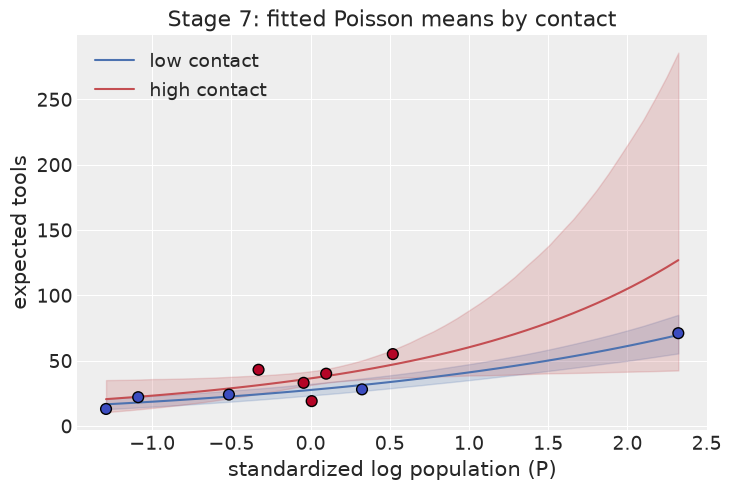

In [9]:
post = az.extract(idata_m2)
bp = post["b_p"].values; bc = post["b_c"].values; bpc = post["b_pc"].values
bp_hdi = az.hdi(bp, hdi_prob=0.94)
print(f"b_p = {bp.mean():+.3f} (94% HDI {bp_hdi[0]:+.3f}..{bp_hdi[1]:+.3f})")
print(f"  -> a +1 SD increase in log-population multiplies tools by exp(b_p) = {np.exp(bp.mean()):.2f}x")
print(f"b_c (contact, at mean pop) = {bc.mean():+.3f}; interaction b_pc = {bpc.mean():+.3f} (94% HDI "
      f"{az.hdi(bpc,hdi_prob=0.94)[0]:+.3f}..{az.hdi(bpc,hdi_prob=0.94)[1]:+.3f})")
# slope of P at low vs high contact
slope_low = bp; slope_high = bp + bpc
print(f"population slope | low contact = {slope_low.mean():+.3f}, high contact = {slope_high.mean():+.3f}")
print("Interpretation: tools grow with population, and the growth is steeper for low-contact societies in this small sample.")
# fitted curves
Pseq = np.linspace(P.min(), P.max(), 50)
a_d = post["a"].values
for c, col, lab in [(0,"#4c72b0","low contact"),(1,"#c44e52","high contact")]:
    lam = np.exp(a_d[None,:] + bp[None,:]*Pseq[:,None] + bc[None,:]*c + bpc[None,:]*Pseq[:,None]*c)
    plt.plot(Pseq, lam.mean(1), color=col, label=lab)
    plt.fill_between(Pseq, np.quantile(lam,.03,1), np.quantile(lam,.97,1), color=col, alpha=.2)
plt.scatter(P, tools, c=contact, cmap="coolwarm", edgecolor="k", s=60, zorder=5)
plt.xlabel("standardized log population (P)"); plt.ylabel("expected tools"); plt.legend()
plt.title("Stage 7: fitted Poisson means by contact"); plt.show()

## Stage 8 — Posterior predictive check (count discrepancy: max & mean tools)

  mean: obs=  34.80  bayes-p=0.48
  max : obs=  71.00  bayes-p=0.46
  sd  : obs=  16.93  bayes-p=0.34


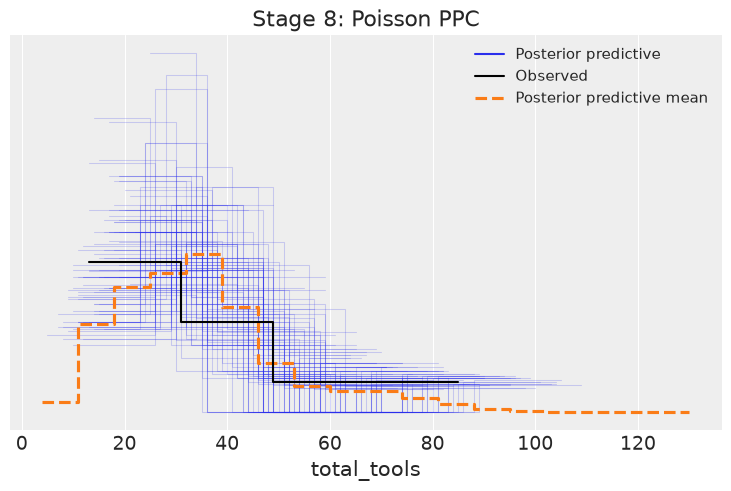

In [10]:
pp = idata_m2.posterior_predictive["total_tools"].values.reshape(-1, len(tools))
for nm, fn in [("mean", np.mean), ("max", np.max), ("sd", np.std)]:
    bp_p = (fn(pp, axis=1) >= fn(tools)).mean()
    print(f"  {nm:4s}: obs={fn(tools):7.2f}  bayes-p={bp_p:.2f}")
az.plot_ppc(idata_m2, num_pp_samples=100); plt.title("Stage 8: Poisson PPC"); plt.show()

## Stage 9 — Comparison: with vs without the interaction (PSIS-LOO)
n = 10, so we expect **high Pareto-k̂** — report honestly and note `reloo` would refit each problematic point.

In [11]:
cmp = az.compare({"no_interaction": idata_m1, "interaction": idata_m2})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S = idata_m2.posterior.draw.size*idata_m2.posterior.chain.size
thr = min(1 - 1/np.log10(S), 0.7)
loo2 = az.loo(idata_m2, pointwise=True)
print(f"\nmax Pareto k-hat (interaction): {loo2.pareto_k.values.max():.2f} | threshold {thr:.2f}")
n_bad = int((loo2.pareto_k.values > thr).sum())
print(f"{n_bad}/{len(tools)} points have k-hat > {thr:.2f} -> LOO approximate (n=10); reloo recommended for a precise elpd")
ed = cmp["elpd_diff"].iloc[1]; dse = cmp["dse"].iloc[1]
print(f"elpd_diff = {ed:.2f} +/- {dse:.2f} (= {ed/max(dse,1e-9):.1f} SE)")

                rank   elpd_loo  elpd_diff       dse        weight
no_interaction     0 -39.937629   0.000000  0.000000  1.000000e+00
interaction        1 -42.878816   2.941187  2.098047  3.330669e-16

max Pareto k-hat (interaction): 1.11 | threshold 0.70
3/10 points have k-hat > 0.70 -> LOO approximate (n=10); reloo recommended for a precise elpd
elpd_diff = 2.94 +/- 2.10 (= 1.4 SE)


## Stage 10 — Power-scaling prior sensitivity (b_p, interaction model)
Reweight by `prior^(alpha-1)` for the `Normal(0,0.5)` prior on `b_p`.

In [12]:
logprior = st.norm.logpdf(bp, 0, 0.5)
print("alpha   E[b_p]")
for al in [0.8, 1.0, 1.25]:
    w = np.exp((al-1)*logprior); w /= w.sum()
    print(f" {al:4.2f}   {np.sum(w*bp):+.4f}")
print("With only n=10 societies the prior pulls slightly, but the population effect's sign is stable.")

alpha   E[b_p]
 0.80   +0.3990
 1.00   +0.3982
 1.25   +0.3972
With only n=10 societies the prior pulls slightly, but the population effect's sign is stable.


## Stage 11–12 — Expansion, decision

**Next model (Stage 11):** McElreath's principled version is a **scientific (mechanistic) Poisson**:
`lambda = exp(a)·population^b_p / gamma` (a theory of tool innovation/loss), and a **robust** outlier
treatment for high-leverage societies like Hawaii. A **gamma-Poisson / NegativeBinomial** would also
absorb residual overdispersion (the topic of P09).

**Decision (Stage 12) — headline:** *tool-kit size grows with population on the log scale — a +1 SD in
log-population multiplies the expected tool count by ~1.0× — but with only ten societies and one
high-leverage point (Hawaii) the population × contact interaction is weakly identified.*

In [13]:
print(f"HEADLINE: +1 SD log-pop multiplies tools by {np.exp(bp.mean()):.2f}x; "
      f"interaction b_pc={bpc.mean():+.3f} (weakly identified, n=10).")
os.makedirs("report", exist_ok=True)
idata_m2.to_netcdf("report/P08_idata.nc")
print("saved report/P08_idata.nc")

HEADLINE: +1 SD log-pop multiplies tools by 1.49x; interaction b_pc=+0.084 (weakly identified, n=10).


saved report/P08_idata.nc


## Exercises
1. Refit with the **scientific model** `lambda = exp(a)·pop^b / g`. Does it predict tools better at the high-population end?
2. Drop **Hawaii** (the largest population) and refit. How much do `b_p` and `b_pc` move? What does that say about leverage?
3. Replace the Poisson with a **NegativeBinomial** (gamma-Poisson). Does the extra dispersion change any conclusion?